# Random Forest with PCA_ESM_Features (Yeast)

Trains a Random Forest regressor to predict protein complex properties (Kd or
stoichiometry) from PCA-compressed ESM-2 embeddings combined with co-expression
and subcellular localisation features.

Pipeline:

  1. Load train / test splits

  2. Compress per-protein ESM-2 embeddings with PCA 
  
  3. Concatenate Cmin and Cmax PCA vectors with tabular biological features

  4. Train a Random Forest (hyperparameters selected via prior GridSearchCV)

  5. Evaluate and visualise predictions

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

## Configuration & Paths

In [63]:
TRAIN_FILE = "/Users/matteo/Desktop//Uttopia_all_shit/ALL_CODE_/B_Dataset_Yeast/Total_Yeast.csv"
TEST_FILE  = "/Users/matteo/Desktop//Uttopia_all_shit/ALL_CODE_/B_Dataset_Yeast/Test_Yeast.csv"
ESM_FILE   = "/Users/matteo/Desktop//Uttopia_all_shit/ALL_CODE_/B_Dataset_Yeast/2_All_protein_esm_yeast.csv"

TARGET = "Kd"   # "Kd" | "int_stoich"
N_COMPONENTS = 0  # PCA components per protein (40 total per pair)
RANDOM_STATE = 42


## Data Loading

In [64]:
test = pd.read_csv(TEST_FILE, index_col=0)
total = pd.read_csv(TRAIN_FILE, index_col=0)

# Exclude test interactions from the training pool
select = test[['Cmin', 'Cmax', 'coex']].rename(columns = {'coex': 'is_test'})
train = total.merge(select, on = ['Cmin', 'Cmax'], how ='left')
train = train[train['is_test'].isna()].drop(columns = ['is_test']).copy()


print(f"Train size: {train.shape[0]}")
print(f"Test size: {test.shape[0]}")

Train size: 15062
Test size: 1551


## PCA Feature Extraction

In [65]:
def process_global_esm_pca(df_train, df_test, esm_file, n_components = N_COMPONENTS):
    """
    Loads the ESM-2 embedding database, fits PCA on all available protein
    embeddings (sequence-space compression, no label leakage), and returns
    PCA feature DataFrames for the train and test sets.

    Each row contains [Cmin_pca_1 … Cmin_pca_N | Cmax_pca_1 … Cmax_pca_N].
    """
    
    esm_df = pd.read_csv(esm_file)
    # Extract protein IDs --> Change to 'gene_id' ("if needed")
    prot_ids = esm_df['gene_name'].astype(str).values
    
    def parse_vector(x):
        try:
            v = ast.literal_eval(x) if isinstance(x, str) else x
            if isinstance(v, (list, np.ndarray)) and len(v) == 320:
                return np.array(v, dtype=np.float32)
        except Exception:
            pass
        return np.zeros(320, dtype=np.float32)
    
    embeddings_list = esm_df['esm_vector'].apply(parse_vector).tolist()
    embeddings = np.array(embeddings_list)
    
    # Fit PCA globally on all available proteins
    pca = PCA(n_components = n_components, random_state = RANDOM_STATE)
    pca_all = pca.fit_transform(embeddings)
    
    
    pca_dict = {pid: vec for pid, vec in zip(prot_ids, pca_all)}
    fallback = np.zeros(n_components, dtype=np.float32) 
    cols = ([f"Cmin_ESM_pca_{i+1}" for i in range(n_components)] + 
            [f"Cmax_ESM_pca_{i+1}" for i in range(n_components)]
      )
    
    # Map PCA features to Cmin and Cmax pairs
    def map_pca(df):
        
        cmin = np.vstack([pca_dict.get(p, fallback) for p in df["Cmin"].astype(str)])
        cmax = np.vstack([pca_dict.get(p, fallback) for p in df["Cmax"].astype(str)])
        
        return pd.DataFrame(np.hstack([cmin, cmax]), columns = cols, index = df.index)

    return map_pca(df_train), map_pca(df_test), pca

train_pca, test_pca, pca  = process_global_esm_pca(train, test, ESM_FILE, N_COMPONENTS)

## Feature Assembly

In [66]:
# With string
#base_cols = [col for col in train.loc[:, 'Cmin_rna':'Cmax_Cell_wall'].columns.tolist()]

# Without string 
base_cols = [col for col in train.loc[:, 'Cmin_rna':'Cmax_Cell_wall'].columns if col != 'string']

X_train = pd.concat([train[base_cols], train_pca], axis=1)
y_train = train[TARGET]

X_test = pd.concat([test[base_cols], test_pca], axis=1)
y_test = test[TARGET]

print(f"Total PCA features extracted: {train_pca.shape[1]}")
print(f"Total features in X_train: {X_train.shape[1]}")

Total PCA features extracted: 0
Total features in X_train: 23


## Model Training

In [67]:
rf = RandomForestRegressor(
    n_estimators = 1500,
    max_depth = 30,
    min_samples_split = 5,
    min_samples_leaf = 2,
    max_features = "sqrt",
    max_samples = 1.0,
    n_jobs = -1,
    random_state = RANDOM_STATE,
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [480]:
## ==========================================
## Salvataggio dei Modelli con Joblib
## ==========================================
import joblib 
import os

# Creiamo la cartella di destinazione se non esiste
OUTPUT_DIR = "/Users/matteo/Desktop/UTTOPIA_RF_ESM/Yeast/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\nSalvataggio dei modelli in corso...")

# 1. Salva il modello PCA (ne basta uno per entrambi i target)
#pca_filename = os.path.join(OUTPUT_DIR, "uttopia_pca_esm_feat_Yeast.joblib")
#joblib.dump(pca, pca_filename, compress=3)
#print(f"✅ PCA salvata: {pca_filename}")

# 2. Salva il modello Random Forest nominandolo in base al TARGET scelto
rf_filename = os.path.join(OUTPUT_DIR, f"uttopia_rf_Yeast_{TARGET.upper()}.joblib")
joblib.dump(rf, rf_filename, compress=3)
print(f"✅ Modello Random Forest ({TARGET}) salvato: {rf_filename}")


Salvataggio dei modelli in corso...
✅ Modello Random Forest (int_stoich) salvato: /Users/matteo/Desktop/UTTOPIA_RF_ESM/Yeast/uttopia_rf_Yeast_INT_STOICH.joblib


## Evaluation 

In [68]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
pearson_r, p = pearsonr(y_test, y_pred)

print("\n" + "="*45)
print(f"--- Test Set Performance ({TARGET}) ---")

print(f"R-squared (R2) Score:           {r2:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Pearson r:                      {pearson_r:.4f}")
print("="*45 + "\n")


--- Test Set Performance (Kd) ---
R-squared (R2) Score:           0.5616
Mean Squared Error (MSE):       0.5402
Pearson r:                      0.7569



## Feature Importance 


Top 10 features:
             Feature  Importance
              string    0.108590
            Cmax_rna    0.075187
                coex    0.048446
            Cmin_rna    0.037771
      Cmax_Cell_wall    0.030757
      Cmin_ESM_pca_4    0.024080
Cmax_Plasma_membrane    0.022042
      Cmax_ESM_pca_1    0.021249
     Cmax_ESM_pca_10    0.019353
        Cmax_Vacuole    0.019314


/var/folders/0d/b_r37hp17mzdhjlcybx6t7lc0000gn/T/ipykernel_45687/2715115910.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Importance", y = "Feature", data = importances.head(10), palette = "tab10")


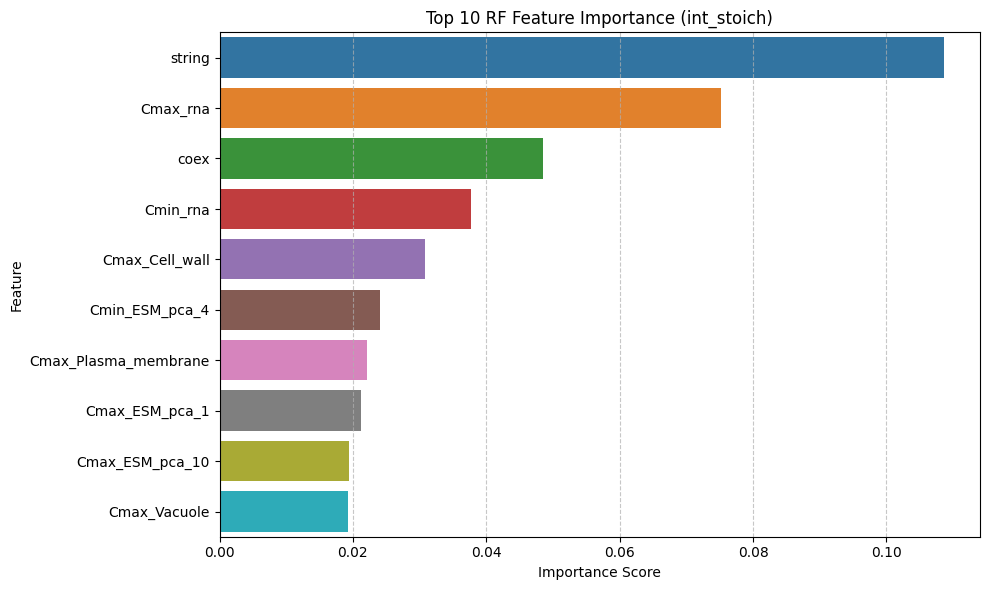

In [482]:
importances = (
    pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_})
    .sort_values("Importance", ascending = False)
)

print("\nTop 10 features:")
print(importances.head(10).to_string(index = False))

plt.figure(figsize = (10, 6))
sns.barplot(x = "Importance", y = "Feature", data = importances.head(10), palette = "tab10")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(f"Top 10 RF Feature Importance ({TARGET})")
plt.grid(axis = "x", linestyle="--", alpha = 0.7)
plt.tight_layout()
#plt.savefig(f"toB_feat_imp{TARGET}.png", dpi = 150)
plt.show()

In [44]:
import pandas as pd

# Creiamo il DataFrame con le prime 66 feature
importances = pd.DataFrame({
    "ID della var": range(len(X_train.columns)), 
    "nome": X_train.columns,
    "valore": rf.feature_importances_
})

# Ordiniamo e prendiamo le prime 66
top_importances = importances.sort_values("valore", ascending=False).head(66)

# (Opzionale) Sostituiamo il punto con la virgola nei numeri, 
# così l'Excel italiano li riconosce subito come numeri e non come testo!
top_importances["valore"] = top_importances["valore"].astype(str).str.replace(".", ",")

# Salviamo in un file CSV usando il punto e virgola come separatore
top_importances.to_csv("risultato_feature.csv", index=False, sep=";")

print("File salvato! Ora fai doppio clic su 'risultato_feature.csv' e si aprirà perfettamente in Excel.")

File salvato! Ora fai doppio clic su 'risultato_feature.csv' e si aprirà perfettamente in Excel.


## Prediction Distribution

FileNotFoundError: [Errno 2] No such file or directory: 'path/toB_kde_dist_int_stoich.png'

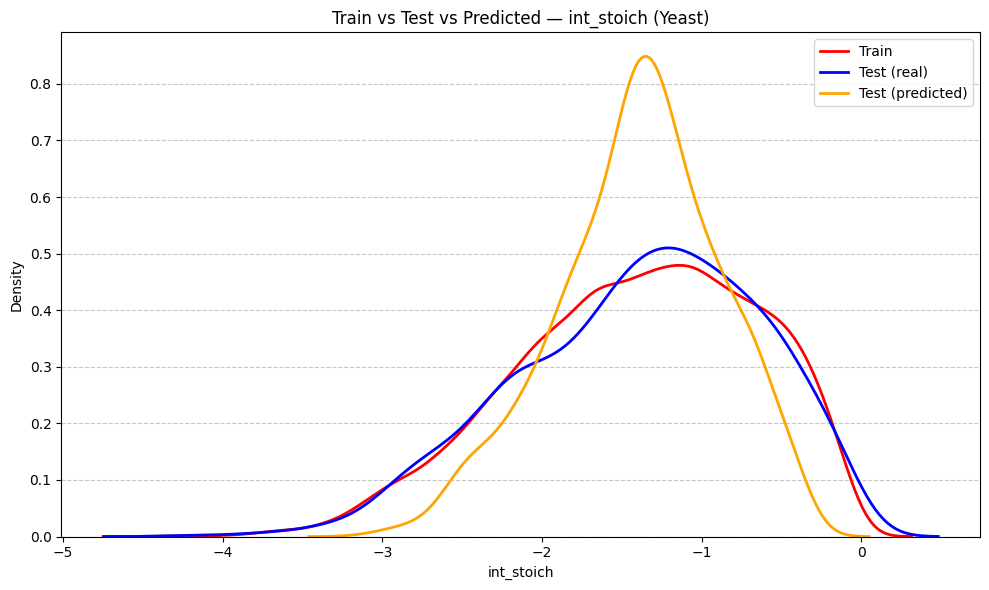

In [484]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_train, label = "Train", color = "red", linewidth=2)
sns.kdeplot(y_test, label = "Test (real)", color = "blue", linewidth = 2)
sns.kdeplot(y_pred, label = "Test (predicted)", color = "orange",linewidth = 2)
plt.xlabel(TARGET)
plt.ylabel("Density")
plt.title(f"Train vs Test vs Predicted — {TARGET} (Yeast)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha = 0.7)
plt.tight_layout()
plt.savefig(f"path/toB_kde_dist_{TARGET}.png", dpi = 150)
plt.show()